In [1]:
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'

Project: 20231010-gen-xii


### Output directory

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Get the best iteration for each target

In [4]:
# load list of targets
str_filename = 'df_targets.csv'
str_uri = f's3://{str_project}/09_early_indicators/input/{str_filename}'
list_str_target = list(pd.read_csv(str_uri)['Target'])
print(f'There are {len(list_str_target)} targets')

There are 141 targets


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:272: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


In [5]:
# get the number of tuning jobs
str_filename = 'df_hyperparameters.csv'
str_uri = f's3://{str_project}/09_early_indicators/input/{str_filename}'
df = pd.read_csv(str_uri)
dict_hyperparameters = dict(zip(df['keys'], df['values']))
int_n_tuning_jobs = int(dict_hyperparameters['INT_N_TUNING_JOBS'])
print(f'There were {int_n_tuning_jobs} tuning jobs')
# get the variant
str_variant = dict_hyperparameters['STR_VARIANT']
print(f'Variant: {str_variant}')

There were 100 tuning jobs
Variant: noPTImodel7


In [6]:
# make output dir
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

In [7]:
list_df = []
for str_target in tqdm(list_str_target):
    for a in range(int_n_tuning_jobs):
        try:
            # read df_output
            str_filename = f'df_output_{a}.csv'
            str_uri = f's3://{str_project}/09_early_indicators/{str_variant}/dfs/{str_target}/df_output_{a}.csv'
            df = pd.read_csv(str_uri)
            # create column
            df['target'] = str_target
            # append
            list_df.append(df)
        except:
            print(f'Cannot find iteration {a} for target {str_target}')
        
df = pd.concat(list_df)

# save
str_filename = 'df_all_models.csv'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
df.to_csv(str_local_path, index=False)

# show
df

100%|██████████| 141/141 [07:27<00:00,  3.17s/it]


,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,best_iteration,target
0,0,0.0010,0.712816,0.777378,0.064563,33,Default_2
0,1,0.0111,0.775188,0.798024,0.022836,59,Default_2
0,2,0.0212,0.964302,0.824890,0.139412,139,Default_2
0,3,0.0312,0.976684,0.731705,0.244979,97,Default_2
0,4,0.0413,0.932195,0.778806,0.153389,47,Default_2
...,...,...,...,...,...,...,...
0,95,0.9587,0.752757,0.724736,0.028022,14,DQ90_24
0,96,0.9688,0.761461,0.723564,0.037897,20,DQ90_24
0,97,0.9788,0.758363,0.723137,0.035226,17,DQ90_24
0,98,0.9889,0.777050,0.724127,0.052924,29,DQ90_24


In [8]:
# get the best model for each target
df_grouped = df.groupby(by='target', as_index=False).agg({
    'flt_eval_metric_valid': 'max',
})
df_grouped

,target,flt_eval_metric_valid
0,DQ15_0,0.808604
1,DQ15_1,0.671800
2,DQ15_10,0.724379
3,DQ15_11,0.726004
4,DQ15_12,0.729058
...,...,...
136,Default_5,0.713483
137,Default_6,0.698981
138,Default_7,0.711955
139,Default_8,0.721978


In [9]:
df_best_models = pd.merge(
    left=df_grouped,
    right=df,
    on=['target','flt_eval_metric_valid'],
    how='left',
)
# re-order
list_cols = [
    'target',
    'iteration',
    'learning_rate',
    'flt_eval_metric_train',
    'flt_eval_metric_valid',
    'diff',
    'best_iteration',
]
df_best_models = df_best_models[list_cols]

# sort
df_best_models.sort_values(by='flt_eval_metric_valid', ascending=False, inplace=True)

# write to csv - local
str_filename = 'df_best_models.csv'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
df_best_models.to_csv(str_local_path, index=False)

# write to csv - s3
str_uri = f's3://{str_project}/09_early_indicators/{str_variant}/best_models/{str_filename}'
df_best_models.to_csv(str_uri, index=False)

# show
df_best_models

,target,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,best_iteration
50,DQ30_0,87,0.8780,0.991305,0.999951,0.008646,19
51,DQ30_1,90,0.9083,0.830589,0.948104,0.117515,18
128,Default_2,66,0.6663,0.779115,0.941510,0.162394,6
0,DQ15_0,88,0.8881,0.892957,0.808604,0.084353,12
42,DQ1_24,4,0.0413,0.817134,0.761187,0.055947,647
...,...,...,...,...,...,...,...
135,Default_4,29,0.2933,0.813136,0.656161,0.156975,6
134,Default_3,6,0.0615,0.916739,0.654901,0.261839,30
37,DQ1_2,2,0.0212,0.717251,0.651871,0.065380,999
26,DQ1_1,4,0.0413,0.726654,0.628821,0.097833,601


### Plot

/tmp/ipykernel_12834/36540471.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_best_models['target'], rotation=90)


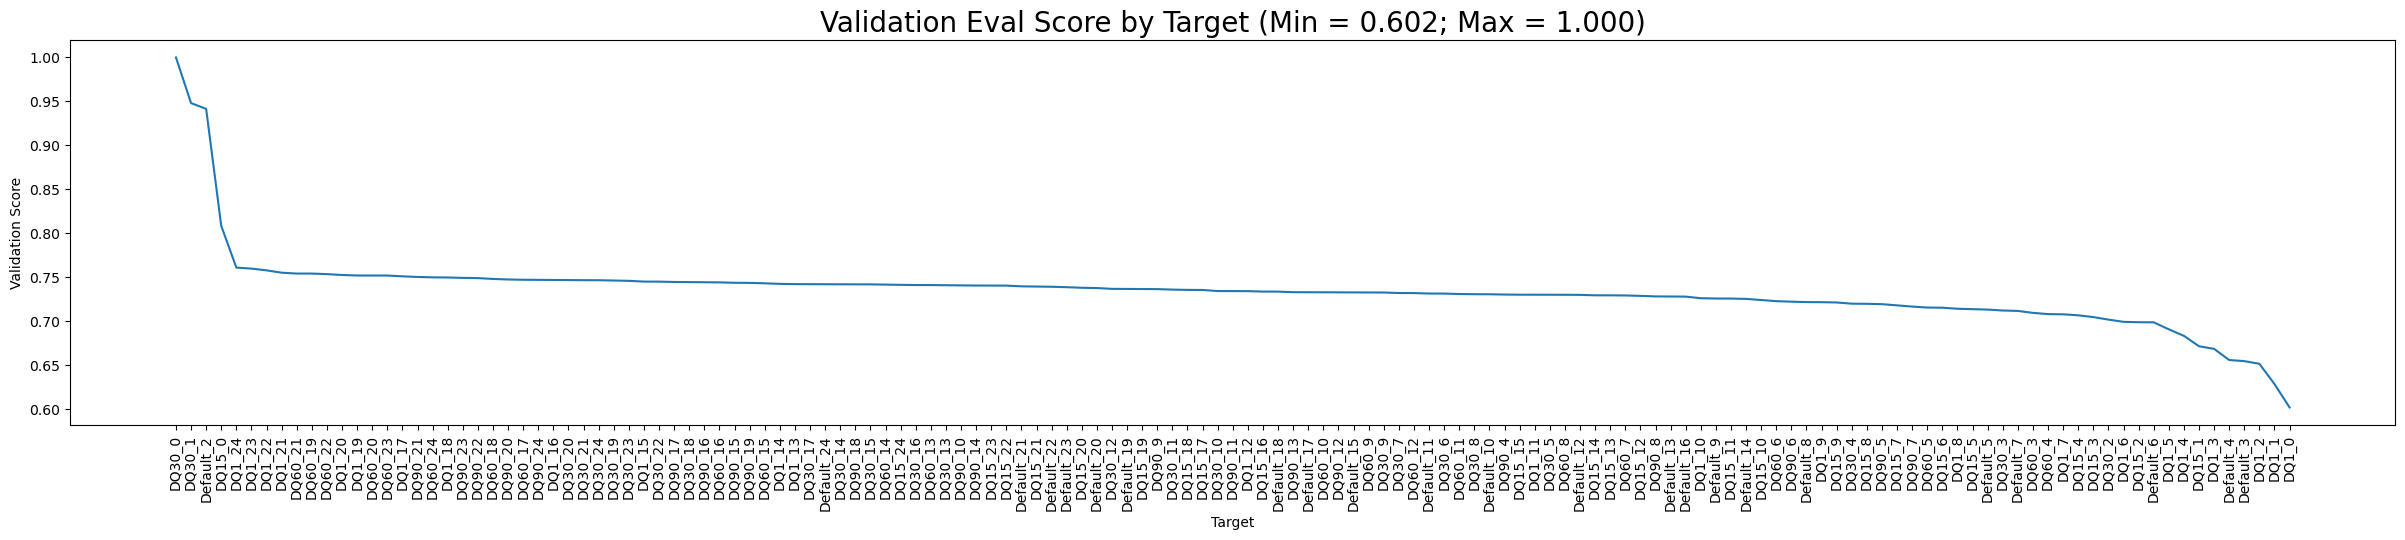

In [10]:
fig, ax = plt.subplots(figsize=(30,5))
flt_min = df_best_models['flt_eval_metric_valid'].min()
flt_max = df_best_models['flt_eval_metric_valid'].max()
str_title = f'Validation Eval Score by Target (Min = {flt_min:0.3f}; Max = {flt_max:0.3f})'
ax.set_title(str_title, fontsize=20)
ax.set_xlabel('Target')
ax.set_ylabel('Validation Score')
ax.plot(df_best_models['target'], df_best_models['flt_eval_metric_valid'])
ax.set_xticklabels(df_best_models['target'], rotation=90)
# show
plt.show()